In [ ]:
import eumdac
import eumdac_tools
import os
import shutil
import zipfile
import datetime as dt
import xarray as xr
import numpy as np

from pyproj import Geod
from pathlib import Path

# Meteosat Third Generation Lightning Imager (MTG-LI) download

Written by: Aiden Jönsson, 2026

This notebook is made for finding, downloading, and processing time series of lightning from the [MTG-LI instrument](https://user.eumetsat.int/resources/user-guides/using-mtg-lightning-imager-li-to-track-convective-storms). The LI instrument detects high-radiance instantaneous flashes and maps them as lightning flashes; groups of flashes are put together for easier handling, with timestamp, geolocation, number of flashes, radiance, and other data quality information given for each. MTG is a geostationary satellite, thus data are available at high time resolution (every 10 minutes), with group-level data being continuous, whenever it is spotted in MTG's line of sight. With this notebook, you can automate the download process from the EUMETSAT data store using their `eumdac` Python package and your credentials for the data store for long time series and create a continuous dataset of lightning near a specific location (by defining a radius around the site for the region of interest).

The following example download is for a two-week period near Mt. Helmos, Greece.

## Accessing the EUMETSAT data store and finding data

In [ ]:
## Get API token from my customer credentials
CONSUMER_KEY = "your_key" # your EUMETSAT store's consumer key
CONSUMER_SECRET = "your_secret" # your EUMETSAT store's consumer secret
token = eumdac.AccessToken((CONSUMER_KEY, CONSUMER_SECRET))
datastore = eumdac.DataStore(token)

## Find collection
collection = datastore.get_collection("EO:EUM:DAT:0782") # EO:EUM:DAT:0782 is LI group-level data; check the store for other collections
products = sorted(
    collection.search(
        dtstart=dt.datetime(2025, 4, 5),
        dtend=dt.datetime(2025, 4, 6),
    ),
    key=lambda p: p.sensing_start
)

## Downloading, subsetting, processing, and saving data

In [ ]:
## Define site location and radius in which to save data from
site_lat = 39.
site_lon = 22.2
radius_km = 100
outfile = "CHOPIN_spring_MTG-LI_LGR_HAC_%skm_radius_TEST" % radius_km

## Main loop
all_timesteps = []
for i, product in enumerate(products):

    print("(%s/%s) Opening: %s" % (i, len(products), product))

    ## Download products
    with product.open() as f:
        with open("tmp_product.zip", "wb") as out : shutil.copyfileobj(f, out)

    ## Extract
    if os.path.exists("tmp_extract") : shutil.rmtree("tmp_extract")
    with zipfile.ZipFile("tmp_product.zip") as z : z.extractall("tmp_extract")

    ## Read BODY chunk files
    body_files = sorted(Path("tmp_extract").glob("*BODY*.nc"))
    chunks = []
    for f in body_files:
        with xr.open_dataset(f) as tmp:
            if tmp.sizes.get("groups", 0) > 0 : chunks.append(tmp.load())

    ## Concatenate if needed
    if len(chunks) == 0 : continue
    elif len(chunks) == 1 : ds = chunks[0]
    else : ds = xr.concat(chunks, dim="groups", data_vars="all")
    for c in chunks : c.close()
    chunks.clear()

    ## Filter for distance from site
    ds = eumdac_tools.subset_radius(ds, site_lat, site_lon, radius_km)

    ## Continue if empty
    if ds.sizes["groups"] == 0:
        shutil.rmtree("tmp_extract")
        os.remove("tmp_product.zip")
        continue
    print("Found %s groups found within radius" % ds.sizes["groups"])
    
    ## Keep only necessary variables and add timestamp
    keep = [
        "latitude",
        "longitude",
        "group_time",
        "radiance",
        "number_of_events",
        "flash_id",
        "group_id",
        "distance_to_site_km"
    ]
    ds = ds[keep]

    ## Append to file
    if not os.path.exists(outfile + ".nc"):
        ds.to_netcdf(outfile + ".nc", mode="w")
    else:
        with xr.open_dataset(outfile + ".nc") as existing:
            existing = existing.load()
        combined = xr.concat(
            [existing, ds],
            dim="groups",
            data_vars="minimal",
            coords="minimal",
            join="override"
        )
        combined.to_netcdf(outfile + ".nc", mode="w")
        combined.close()
        existing.close()

    ## Cleanup
    shutil.rmtree("tmp_extract")
    os.remove("tmp_product.zip")

## Convert to Pandas dataframe and save as `.csv` file if desired

In [6]:
import pandas as pd

outfile = "CHOPIN_spring_MTG-LI_LGR_HAC_100km_radius"
ds = xr.open_dataset("../processed_EUMETSAT/" + outfile + ".nc")
df = (
    ds
    .to_dataframe()
    .reset_index()
    .drop(columns="groups")
)
df["group_time"] = pd.to_datetime(df["group_time"])
df = df.sort_values("group_time")
df.set_index("group_time", inplace=True)
df.to_csv(outfile + ".csv")

# Example plot

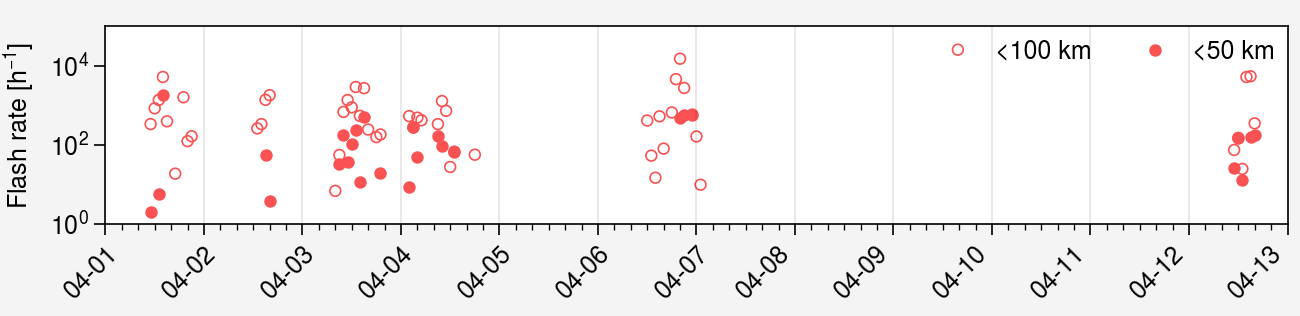

In [7]:
import ultraplot as uplt
import matplotlib as mpl

date_lim = [pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-13")]
fig, ax = uplt.subplots(
    refwidth='15cm',
    refaspect=6,
    facecolor='w',
    grid=False
)

## Plot flash rates
li_50km = df[df["distance_to_site_km"] < 50]
ax.scatter(
    df['number_of_events'].resample('1h').sum(),
    ec='red6',
    fc='none',
    ms=15,
    label='<100 km'
)
ax.scatter(
    li_50km['number_of_events'].resample('1h').sum(),
    c='red6',
    ms=15,
    label='<50 km'
)
ax.format(
    ylabel='Flash rate [$\mathrm{h^{-1}}$]',
    ylim=[1e0, 1e5],
    yscale='log',
    yformatter='math',
    xlim=[date_lim[0], date_lim[1]],
    xlocator=mpl.dates.DayLocator(interval=1),
    xminorlocator=mpl.dates.HourLocator(interval=4),
    xformatter="%m-%d",
    xrotation=45,
    xgrid=True,
    xgridminor=False,
    xlabel="",
)
ax.legend(loc='ur', frameon=False)